<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Spruce_Goose_and_IBM_Quantum_Computer_Shared_Lineage_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

There is a  historical lineage through the ambitious industrial enterprises of Howard Hughes. Initially, the Hughes Aircraft Company (HAC) engineered the Hughes H4 Hercules (which historians colloquially reference as the Spruce Goose) to function as an experimental transatlantic transport vehicle. Since Howard Hughes desired to expand his scientific capabilities following this monumental aviation achievement, the parent corporation established a dedicated experimental division named Hughes Research and Development Laboratories. This specialized research branch eventually matured into an independent commercial entity known as Hughes Research Laboratories (HRL) Limited Liability Company (LLC), which subsequently pioneered highly advanced silicon spin qubits for solid state quantum computing. Because International Business Machines (IBM) actively sought to broaden its hardware roadmap, the technology conglomerate officially acquired HRL Laboratories from its previous joint owners, Boeing and General Motors (GM), on July 23, 2026. Consequently, this strategic corporate integration directly merges the advanced silicon spin qubit architectures developed by HRL Laboratories with the established superconducting qubit platforms that IBM Quantum computers currently utilize.

Using Python 3.12.13 environment at: /usr
Checked 3 packages in 200ms


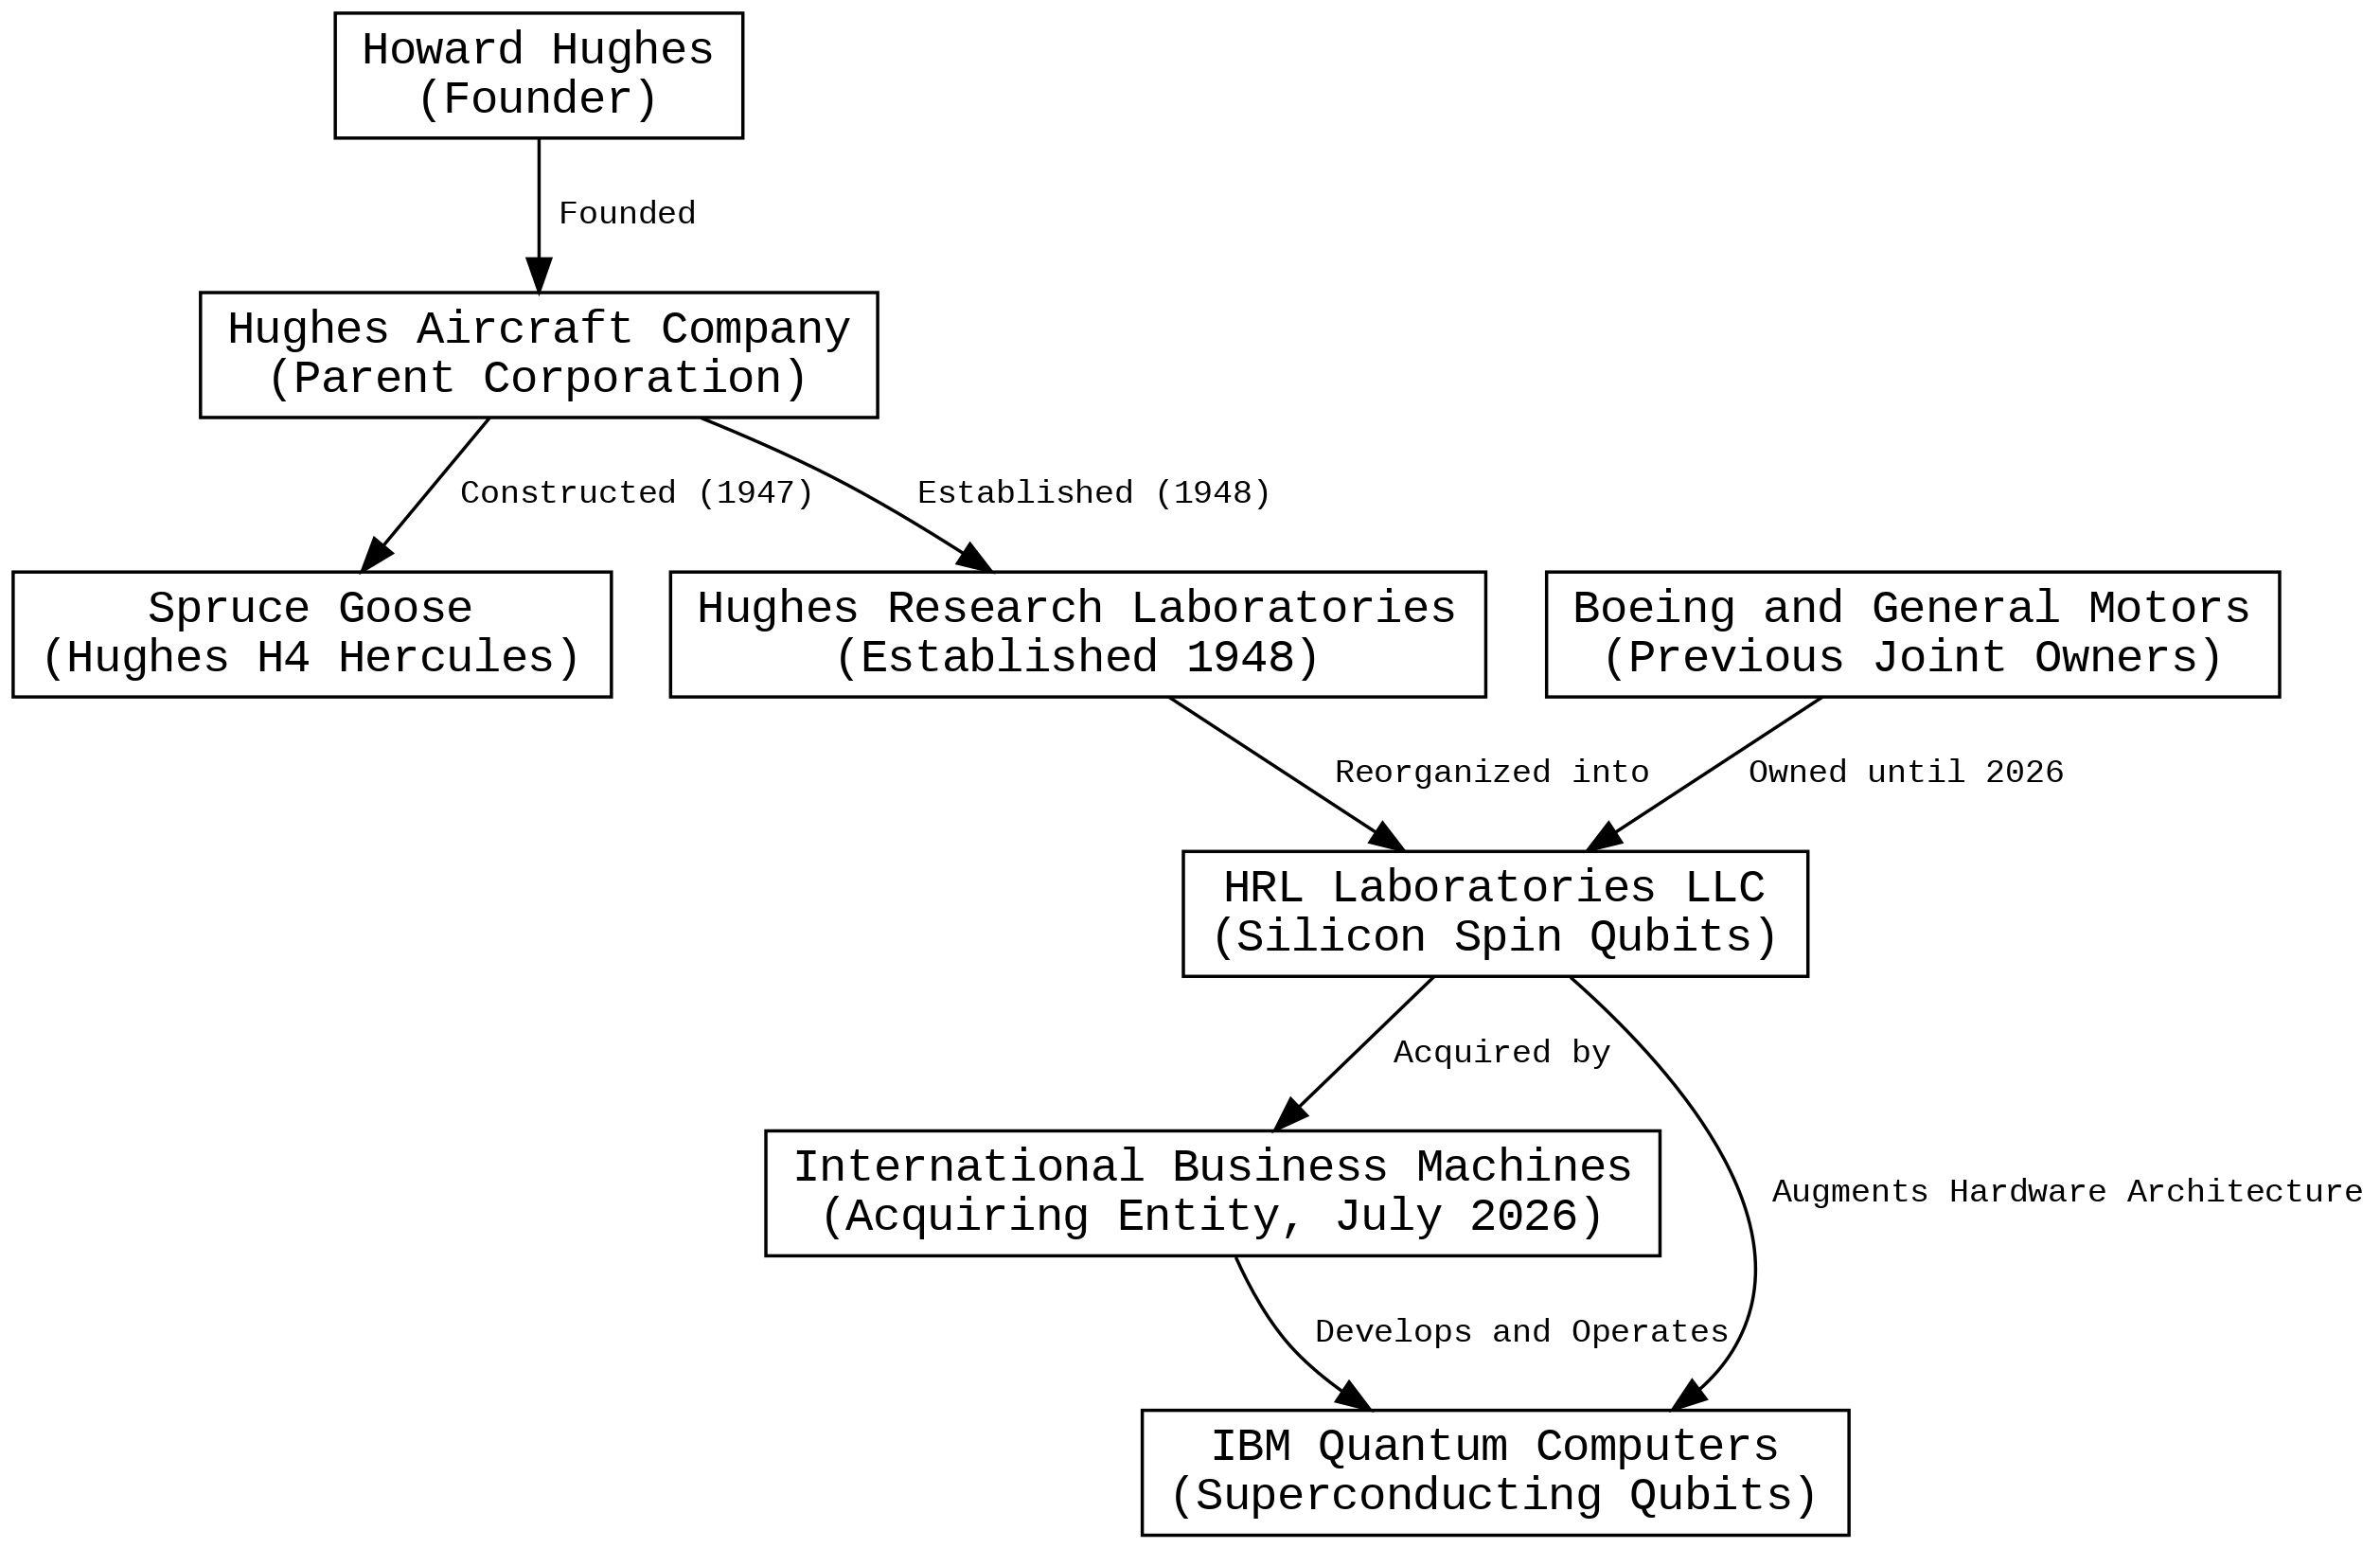

In [2]:
!uv pip install graphviz matplotlib ipython

"""This script generates a Graphviz visualization of organizational lineages in memory.

The application maps the historical connections between Howard Hughes, the Spruce Goose,
Hughes Research Laboratories, and International Business Machines (IBM), which utilizes
an internal memory rendering technique to produce a Portable Network Graphics (PNG)
image without writing to a physical disk.
"""

import graphviz
import matplotlib.pyplot as plt
from IPython.display import Image, display

# --- Control Knobs ---
FONT_NAME = "Tahoma"
GRAPH_DPI = "250"  # Dots Per Inch
NODE_SHAPE = "box"
NODE_STYLE = "filled"
NODE_FILL_COLOR = "white"
EDGE_FONT_SIZE = "10"
OUTPUT_FORMAT = "png"
# ---------------------

# Matplotlib rcParams configuration to satisfy environment styling preferences
plt.rcParams['figure.dpi'] = int(GRAPH_DPI)
plt.rcParams['font.sans-serif'] = [FONT_NAME, 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'

def create_lineage_graph() -> graphviz.Digraph:
    """Creates a directed graph connecting Hughes Aircraft to IBM Quantum.

    Returns:
        graphviz.Digraph: The compiled Graphviz directed graph object.
    """
    directed_graph = graphviz.Digraph(comment="Innovation Lineage")

    directed_graph.attr(dpi=GRAPH_DPI)
    directed_graph.attr("node", shape=NODE_SHAPE, style=NODE_STYLE, fillcolor=NODE_FILL_COLOR, fontname=FONT_NAME)
    directed_graph.attr("edge", fontname=FONT_NAME, fontsize=EDGE_FONT_SIZE)

    directed_graph.node("HH", "Howard Hughes\n(Founder)")
    directed_graph.node("HAC", "Hughes Aircraft Company\n(Parent Corporation)")
    directed_graph.node("SG", "Spruce Goose\n(Hughes H4 Hercules)")
    directed_graph.node("HL", "Hughes Research Laboratories\n(Established 1948)")
    directed_graph.node("HRL", "HRL Laboratories LLC\n(Silicon Spin Qubits)")
    directed_graph.node("BGM", "Boeing and General Motors\n(Previous Joint Owners)")
    directed_graph.node("IBM", "International Business Machines\n(Acquiring Entity, July 2026)")
    directed_graph.node("IBMQ", "IBM Quantum Computers\n(Superconducting Qubits)")

    directed_graph.edge("HH", "HAC", label=" Founded")
    directed_graph.edge("HAC", "SG", label=" Constructed (1947)")
    directed_graph.edge("HAC", "HL", label=" Established (1948)")
    directed_graph.edge("HL", "HRL", label=" Reorganized into")
    directed_graph.edge("BGM", "HRL", label=" Owned until 2026")
    directed_graph.edge("HRL", "IBM", label=" Acquired by")
    directed_graph.edge("IBM", "IBMQ", label=" Develops and Operates")
    directed_graph.edge("HRL", "IBMQ", label=" Augments Hardware Architecture")

    return directed_graph


def render_graph_in_memory(directed_graph: graphviz.Digraph) -> bytes:
    """Extracts the raw image bytes from the Graphviz object.

    Args:
        directed_graph: The constructed Graphviz directed graph.

    Returns:
        bytes: The raw byte sequence of the rendered image.
    """
    return directed_graph.pipe(format=OUTPUT_FORMAT)


def main() -> None:
    """Executes the graph generation and prepares it for Colab display."""
    lineage_graph = create_lineage_graph()
    image_bytes = render_graph_in_memory(lineage_graph)
    display(Image(data=image_bytes, format=OUTPUT_FORMAT))


if __name__ == "__main__":
    main()